In [35]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from shapely.geometry import Point
import rasterio
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")
print(f"GeoPandas version: {gpd.__version__}")
print(f"Rasterio version: {rasterio.__version__}")

✅ All libraries imported successfully
GeoPandas version: 1.1.3
Rasterio version: 1.4.4


In [46]:
# Set your project path
project_path = r"c:\Users\PC\OneDrive\Desktop\Data Science\PERSONAL PROJECTS\Flood analysis"

# Define file paths
dem_path = os.path.join(project_path, "Kenya_SRTM30meters.tif")

# Counties folder (contains County.shp, etc.)
counties_folder = os.path.join(project_path, "kenyan-counties")

# Towns folder
towns_folder = os.path.join(project_path, "Kenya_Towns")

# Land cover folders (each contains .shp file)
landcover_folders = {
    'bareareas': os.path.join(project_path, "ke_bareareas"),
    'floodplains': os.path.join(project_path, "ke_floodplains"),
    'forests': os.path.join(project_path, "ke_forests"),
    'mangroves': os.path.join(project_path, "ke_mangroves"),
    'protected_areas': os.path.join(project_path, "ke_protected-areas"),
    'rangeland': os.path.join(project_path, "ke_rangeland"),
    'sandbeaches': os.path.join(project_path, "ke_sand_beaches"),
    'urban_areas': os.path.join(project_path, "ke_urban"),
    'waterbodies': os.path.join(project_path, "ke_waterbodies"),
    'wetlands': os.path.join(project_path, "ke_wetlands"),
}

# Output paths
output_folder = os.path.join(project_path, "outputs")
resampled_dem_folder = os.path.join(output_folder, "resampled_dem")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(resampled_dem_folder, exist_ok=True)

print(f"✅ Project path: {project_path}")
print(f"✅ Output folder: {output_folder}")

# Verify files exist
print(f"\n📁 File existence check:")
print(f"  DEM exists: {os.path.exists(dem_path)}")
print(f"  Counties folder exists: {os.path.exists(counties_folder)}")
print(f"  Towns folder exists: {os.path.exists(towns_folder)}")

# Check DEM alternative name
if not os.path.exists(dem_path):
    alt_dem = os.path.join(project_path, "kenya_srtm30meters.tif")
    if os.path.exists(alt_dem):
        dem_path = alt_dem
        print(f"  Using alternative DEM: {alt_dem}")
    else:
        print(f"  ⚠️ DEM not found at either location")
        print(f"     Tried: {dem_path}")
        print(f"     Tried: {alt_dem}")

# Check counties folder contents
if os.path.exists(counties_folder):
    print(f"\n📂 Counties folder contents:")
    for file in os.listdir(counties_folder):
        if file.endswith('.shp'):
            print(f"  📄 {file} (main shapefile)")
        elif file.endswith(('.shx', '.dbf', '.prj')):
            print(f"     {file}")

✅ Project path: c:\Users\PC\OneDrive\Desktop\Data Science\PERSONAL PROJECTS\Flood analysis
✅ Output folder: c:\Users\PC\OneDrive\Desktop\Data Science\PERSONAL PROJECTS\Flood analysis\outputs

📁 File existence check:
  DEM exists: True
  Counties folder exists: True
  Towns folder exists: True

📂 Counties folder contents:
     County.dbf
     County.prj
  📄 County.shp (main shapefile)
     County.shx


In [62]:
# Load DEM and check its CRS
print("📊 LOADING DEM AND CHECKING CRS...")

with rasterio.open(dem_path) as src:
    dem_crs_original = src.crs
    dem_bounds_original = src.bounds
    print(f"  Original DEM CRS: {dem_crs_original}")
    print(f"  Original DEM bounds: {dem_bounds_original}")

# Check if DEM is in degrees (geographic) or meters (projected)
if dem_crs_original.is_geographic:
    print(f"\n⚠️ DEM is in geographic coordinates (degrees). Converting to projected CRS...")
    
    # Target CRS (same as points)
    target_crs = "EPSG:32737"  # UTM zone 37S
    
    # Create resampled DEM in projected CRS
    resampled_dem_path = os.path.join(resampled_dem_folder, "kenya_dem_utm.tif")
    
    from rasterio.warp import calculate_default_transform, reproject, Resampling
    
    with rasterio.open(dem_path) as src:
        # Calculate transform for target CRS
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height,
            *src.bounds, resolution=90  # 90m resolution
        )
        
        # Update profile
        profile = src.profile.copy()
        profile.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height,
            'compress': 'lzw'
        })
        
        # Reproject
        dem_data_projected = np.zeros((height, width), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=dem_data_projected,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=target_crs,
            resampling=Resampling.bilinear
        )
        
        # Write reprojected DEM
        with rasterio.open(resampled_dem_path, 'w', **profile) as dst:
            dst.write(dem_data_projected, 1)
        
        dem_bounds = transform * (0, 0), transform * (width, height)
        dem_crs = target_crs
        dem_width = width
        dem_height = height
        
    print(f"  ✅ DEM reprojected to {target_crs}")
    print(f"  New bounds (meters): {dem_bounds}")
    print(f"  New size: {width:,} x {height:,} pixels")
    
    # Update DEM path
    dem_path = resampled_dem_path
else:
    print(f"\n✅ DEM already in projected CRS: {dem_crs_original}")
    dem_crs = dem_crs_original
    dem_bounds = dem_bounds_original
    
print(f"\n✅ Using DEM: {dem_path}")

📊 LOADING DEM AND CHECKING CRS...
  Original DEM CRS: EPSG:4326
  Original DEM bounds: BoundingBox(left=33.90958333333333, bottom=-4.720694444444433, right=41.887638888888866, top=4.634027777777764)

⚠️ DEM is in geographic coordinates (degrees). Converting to projected CRS...
  ✅ DEM reprojected to EPSG:32737
  New bounds (meters): ((-67187.46785368305, 10514243.507257441), (821472.532146317, 9476093.507257441))
  New size: 9,874 x 11,535 pixels

✅ Using DEM: c:\Users\PC\OneDrive\Desktop\Data Science\PERSONAL PROJECTS\Flood analysis\outputs\resampled_dem\kenya_dem_utm.tif


In [41]:
# Load counties shapefile from folder
print("📊 LOADING COUNTIES...")

if os.path.exists(counties_folder):
    # Find the .shp file in the folder
    counties_shp = None
    for file in os.listdir(counties_folder):
        if file.endswith('.shp'):
            counties_shp = os.path.join(counties_folder, file)
            break
    
    if counties_shp and os.path.exists(counties_shp):
        counties_gdf = gpd.read_file(counties_shp)
        print(f"✅ Counties loaded: {len(counties_gdf)} features")
        print(f"  CRS: {counties_gdf.crs}")
        print(f"  Columns: {counties_gdf.columns.tolist()}")
        
        # List of 47 Kenyan counties
        kenya_counties = [
            "Mombasa", "Kwale", "Kilifi", "Tana River", "Lamu", "Taita Taveta",
            "Garissa", "Wajir", "Mandera", "Marsabit", "Isiolo", "Meru",
            "Tharaka Nithi", "Embu", "Kitui", "Machakos", "Makueni",
            "Nyandarua", "Nyeri", "Kirinyaga", "Murang'a", "Kiambu",
            "Turkana", "West Pokot", "Samburu", "Trans Nzoia", "Uasin Gishu",
            "Elgeyo Marakwet", "Nandi", "Baringo", "Laikipia", "Nakuru",
            "Narok", "Kajiado", "Kericho", "Bomet", "Kakamega", "Vihiga",
            "Bungoma", "Busia", "Siaya", "Kisumu", "Homa Bay", "Migori",
            "Kisii", "Nyamira", "Nairobi"
        ]
        
        # Find or create county name column
        name_col = None
        for col in ['COUNTY', 'COUNTY_NAM', 'NAME', 'county', 'name', 'District', 'COUNTY_NAME']:
            if col in counties_gdf.columns:
                name_col = col
                break
        
        if name_col:
            counties_gdf['COUNTY_NAME'] = counties_gdf[name_col]
            print(f"✅ Using '{name_col}' as county names")
        elif len(counties_gdf) == len(kenya_counties):
            counties_gdf['COUNTY_NAME'] = kenya_counties
            print(f"✅ Added official county names based on order (47 counties)")
        else:
            counties_gdf['COUNTY_NAME'] = [f"County_{i+1}" for i in range(len(counties_gdf))]
            print(f"⚠️ Created generic names for {len(counties_gdf)} counties")
        
        # Save labeled counties
        labeled_counties_path = os.path.join(output_folder, "kenya_counties_labeled.shp")
        counties_gdf.to_file(labeled_counties_path)
        print(f"✅ Labeled counties saved to {labeled_counties_path}")
        
        # Display first few counties
        print(f"\n📊 First 10 counties:")
        print(counties_gdf['COUNTY_NAME'].head(10).tolist())
        
    else:
        print(f"❌ No .shp file found in {counties_folder}")
        raise FileNotFoundError(f"No shapefile in {counties_folder}")
else:
    print(f"❌ Counties folder not found: {counties_folder}")
    raise FileNotFoundError(f"Counties folder missing at {counties_folder}")

📊 LOADING COUNTIES...
✅ Counties loaded: 47 features
  CRS: EPSG:4326
  Columns: ['OBJECTID', 'AREA', 'PERIMETER', 'COUNTY3_', 'COUNTY3_ID', 'COUNTY', 'Shape_Leng', 'Shape_Area', 'geometry']
✅ Using 'COUNTY' as county names
✅ Labeled counties saved to c:\Users\PC\OneDrive\Desktop\Data Science\PERSONAL PROJECTS\Flood analysis\outputs\kenya_counties_labeled.shp

📊 First 10 counties:
['Turkana', 'Marsabit', 'Mandera', 'Wajir', 'West Pokot', 'Samburu', 'Isiolo', 'Baringo', 'Keiyo-Marakwet', 'Trans Nzoia']


In [42]:
# Load major towns shapefile
print("📊 LOADING MAJOR TOWNS...")

towns_gdf = None
if os.path.exists(towns_folder):
    towns_shp = None
    for file in os.listdir(towns_folder):
        if file.endswith('.shp'):
            towns_shp = os.path.join(towns_folder, file)
            break
    
    if towns_shp:
        towns_gdf = gpd.read_file(towns_shp)
        print(f"✅ Towns loaded: {len(towns_gdf)} features")
        
        # Identify town name column
        name_column = None
        for col in ['NAME', 'TOWN', 'CITY', 'LOCALITY', 'name', 'town', 'city', 'TOWN_NAME']:
            if col in towns_gdf.columns:
                name_column = col
                break
        
        if name_column:
            towns_gdf['town_name'] = towns_gdf[name_column].fillna('Unknown')
            print(f"✅ Using '{name_column}' as town name")
        else:
            towns_gdf['town_name'] = [f"Town_{i+1}" for i in range(len(towns_gdf))]
        
        # Categorize towns by size
        major_cities = ['Nairobi', 'Mombasa', 'Kisumu', 'Nakuru', 'Eldoret', 'Thika', 'Malindi']
        towns_gdf['town_size'] = 'Town'
        towns_gdf.loc[towns_gdf['town_name'].isin(major_cities), 'town_size'] = 'Major City'
        print(f"  Town size distribution: {towns_gdf['town_size'].value_counts().to_dict()}")
        
        # Save labeled towns
        labeled_towns_path = os.path.join(output_folder, "kenya_towns_labeled.shp")
        towns_gdf.to_file(labeled_towns_path)
        print(f"✅ Labeled towns saved")
    else:
        print("⚠️ No shapefile found in towns folder")
else:
    print("⚠️ Towns folder not found")

📊 LOADING MAJOR TOWNS...
✅ Towns loaded: 1620 features
✅ Using 'TOWN_NAME' as town name
  Town size distribution: {'Town': 1614, 'Major City': 6}
✅ Labeled towns saved


In [53]:
# Convert counties to a projected CRS for meter-based calculations
print("🔄 CONVERTING TO PROJECTED CRS (METERS)...")

# Check current CRS
print(f"  Original counties CRS: {counties_gdf.crs}")

# Convert to UTM zone 37N (covers most of Kenya, uses meters)
# EPSG:32737 is WGS84 / UTM zone 37S (for southern hemisphere)
target_crs = "EPSG:32737"  # UTM zone 37S - meters

# Convert counties
counties_gdf_projected = counties_gdf.to_crs(target_crs)
print(f"  New counties CRS: {counties_gdf_projected.crs}")
print(f"  New bounds (meters): {counties_gdf_projected.total_bounds}")

# Get Kenya bounds in meters
kenya_bounds_meters = counties_gdf_projected.total_bounds
print(f"\n📊 Kenya bounds in meters:")
print(f"  Min X: {kenya_bounds_meters[0]:.0f}m")
print(f"  Min Y: {kenya_bounds_meters[1]:.0f}m")
print(f"  Max X: {kenya_bounds_meters[2]:.0f}m")
print(f"  Max Y: {kenya_bounds_meters[3]:.0f}m")
print(f"  Width: {kenya_bounds_meters[2] - kenya_bounds_meters[0]:.0f}m")
print(f"  Height: {kenya_bounds_meters[3] - kenya_bounds_meters[1]:.0f}m")

# Convert towns if they exist
if towns_gdf is not None:
    towns_gdf_projected = towns_gdf.to_crs(target_crs)
    print(f"\n✅ Towns converted to {target_crs}")
else:
    towns_gdf_projected = None

# Convert landcover data - handling files without CRS
print(f"\n🔄 Converting landcover data...")
landcover_gdf_projected = {}

for name, gdf in landcover_gdf.items():
    try:
        # Check if CRS is missing
        if gdf.crs is None:
            print(f"  ⚠️ {name} has no CRS. Assuming WGS84 (EPSG:4326)...")
            gdf = gdf.set_crs("EPSG:4326")
        
        # Convert to target CRS
        landcover_gdf_projected[name] = gdf.to_crs(target_crs)
        print(f"  ✅ Converted {name} to {target_crs}")
    except Exception as e:
        print(f"  ❌ Failed to convert {name}: {e}")

# Update the main GeoDataFrames
counties_gdf = counties_gdf_projected
if towns_gdf is not None:
    towns_gdf = towns_gdf_projected
landcover_gdf = landcover_gdf_projected

print(f"\n✅ All data now in projected CRS: {target_crs}")

🔄 CONVERTING TO PROJECTED CRS (METERS)...
  Original counties CRS: EPSG:4326
  New counties CRS: EPSG:32737
  New bounds (meters): [  -66936.94704644  9480233.05097434   822758.42929784 10601528.12183757]

📊 Kenya bounds in meters:
  Min X: -66937m
  Min Y: 9480233m
  Max X: 822758m
  Max Y: 10601528m
  Width: 889695m
  Height: 1121295m

✅ Towns converted to EPSG:32737

🔄 Converting landcover data...
  ✅ Converted bareareas to EPSG:32737
  ✅ Converted floodplains to EPSG:32737
  ✅ Converted forests to EPSG:32737
  ✅ Converted mangroves to EPSG:32737
  ✅ Converted protected_areas to EPSG:32737
  ✅ Converted rangeland to EPSG:32737
  ✅ Converted sandbeaches to EPSG:32737
  ✅ Converted urban_areas to EPSG:32737
  ⚠️ waterbodies has no CRS. Assuming WGS84 (EPSG:4326)...
  ✅ Converted waterbodies to EPSG:32737
  ✅ Converted wetlands to EPSG:32737

✅ All data now in projected CRS: EPSG:32737


In [54]:
# Load all land cover shapefiles
print("📊 LOADING LAND COVER SHAPEFILES...")

landcover_gdf = {}
landcover_risk_weights = {
    'floodplains': 10, 'waterbodies': 9, 'wetlands': 8, 'sandbeaches': 7,
    'urban_areas': 6, 'bareareas': 5, 'rangeland': 3, 'forests': 1,
    'mangroves': 1, 'protected_areas': 1
}

for name, folder_path in landcover_folders.items():
    if os.path.exists(folder_path):
        shp_file = None
        for file in os.listdir(folder_path):
            if file.endswith('.shp'):
                shp_file = os.path.join(folder_path, file)
                break
        
        if shp_file:
            try:
                gdf = gpd.read_file(shp_file)
                landcover_gdf[name] = gdf
                print(f"  ✅ Loaded {name}: {len(gdf):,} features")
            except Exception as e:
                print(f"  ❌ Failed to load {name}: {e}")
        else:
            print(f"  ⚠️ No shapefile in {folder_path}")
    else:
        print(f"  ⚠️ Folder not found: {name}")

print(f"\n✅ Loaded {len(landcover_gdf)} land cover datasets")

📊 LOADING LAND COVER SHAPEFILES...
  ✅ Loaded bareareas: 126 features
  ✅ Loaded floodplains: 162 features
  ✅ Loaded forests: 4,764 features
  ✅ Loaded mangroves: 284 features
  ✅ Loaded protected_areas: 203 features
  ✅ Loaded rangeland: 3,270 features
  ✅ Loaded sandbeaches: 44 features
  ✅ Loaded urban_areas: 260 features
  ✅ Loaded waterbodies: 208 features
  ✅ Loaded wetlands: 1,226 features

✅ Loaded 10 land cover datasets


🔄 CREATING SAMPLING POINTS IN METERS...
  Kenya bounds (meters): X: -66937 to 822758, Y: 9480233 to 10601528
  Grid: 178 x 225 = 40,050 points
  Adjusting spacing to 6329m to limit to ~25,000 points
  New grid: 141 x 178 = 25,098 points

✅ Created 25,098 sample points
  Spacing: 6,328 meters (6.3km)
  Points CRS: EPSG:32737
  X range: -66937 to 818983 meters
  Y range: 9480233 to 10600289 meters


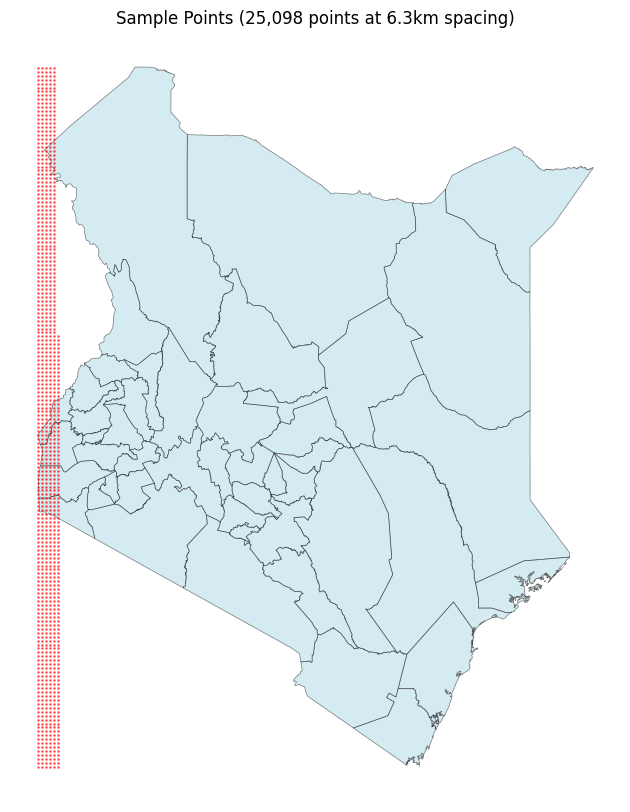

✅ Preview saved to outputs/sampling_points_preview.png


In [55]:
# Create sampling points across Kenya using projected CRS (meters)
print("🔄 CREATING SAMPLING POINTS IN METERS...")

# Get Kenya bounds in meters
kenya_bounds = counties_gdf.total_bounds
print(f"  Kenya bounds (meters): X: {kenya_bounds[0]:.0f} to {kenya_bounds[2]:.0f}, Y: {kenya_bounds[1]:.0f} to {kenya_bounds[3]:.0f}")

# Set spacing in meters (now this makes sense!)
spacing_meters = 5000  # 5km = 5000 meters

# Create grid
x_coords = np.arange(kenya_bounds[0], kenya_bounds[2], spacing_meters)
y_coords = np.arange(kenya_bounds[1], kenya_bounds[3], spacing_meters)

total_points = len(x_coords) * len(y_coords)
print(f"  Grid: {len(x_coords)} x {len(y_coords)} = {total_points:,} points")

# Limit points if too many
max_points = 25000
if total_points > max_points:
    # Calculate factor to reduce points
    factor = (total_points / max_points) ** 0.5
    new_spacing = spacing_meters * factor
    print(f"  Adjusting spacing to {new_spacing:.0f}m to limit to ~{max_points:,} points")
    
    spacing_meters = int(new_spacing)
    x_coords = np.arange(kenya_bounds[0], kenya_bounds[2], spacing_meters)
    y_coords = np.arange(kenya_bounds[1], kenya_bounds[3], spacing_meters)
    total_points = len(x_coords) * len(y_coords)
    print(f"  New grid: {len(x_coords)} x {len(y_coords)} = {total_points:,} points")

# Create points
points = []
for x in x_coords:
    for y in y_coords:
        points.append(Point(x, y))

# Create GeoDataFrame
points_gdf = gpd.GeoDataFrame(geometry=points, crs=counties_gdf.crs)

print(f"\n✅ Created {len(points_gdf):,} sample points")
print(f"  Spacing: {spacing_meters:,} meters ({spacing_meters/1000:.1f}km)")
print(f"  Points CRS: {points_gdf.crs}")
print(f"  X range: {points_gdf.geometry.x.min():.0f} to {points_gdf.geometry.x.max():.0f} meters")
print(f"  Y range: {points_gdf.geometry.y.min():.0f} to {points_gdf.geometry.y.max():.0f} meters")

# Quick visualization of first 1000 points
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
counties_gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', alpha=0.5, linewidth=0.5)
points_gdf.head(1000).plot(ax=ax, markersize=1, color='red', alpha=0.5)
ax.set_title(f'Sample Points ({len(points_gdf):,} points at {spacing_meters/1000:.1f}km spacing)', fontsize=12)
ax.set_axis_off()
plt.savefig(os.path.join(output_folder, 'sampling_points_preview.png'), dpi=150)
plt.show()
print(f"✅ Preview saved to outputs/sampling_points_preview.png")

In [56]:
# Assign each point to a county
print("🔄 ASSIGNING POINTS TO COUNTIES...")

# Perform spatial join using 'within' (points inside polygons)
print("  Performing spatial join...")
points_with_counties = gpd.sjoin(points_gdf, 
                                  counties_gdf[['COUNTY_NAME', 'geometry']], 
                                  how='left', 
                                  predicate='within')

df = points_with_counties.copy()
df['county'] = df['COUNTY_NAME']

# Check results
assigned_count = df['county'].notna().sum()
print(f"\n✅ Points assigned: {assigned_count:,} / {len(df):,} ({assigned_count/len(df)*100:.1f}%)")

if assigned_count == 0:
    print("\n⚠️ No points assigned with 'within'. Trying 'intersects'...")
    points_with_counties = gpd.sjoin(points_gdf, 
                                      counties_gdf[['COUNTY_NAME', 'geometry']], 
                                      how='left', 
                                      predicate='intersects')
    df = points_with_counties.copy()
    df['county'] = df['COUNTY_NAME']
    assigned_count = df['county'].notna().sum()
    print(f"Points assigned with 'intersects': {assigned_count:,} / {len(df):,}")

# If still no points, check if points are outside county bounds
if assigned_count == 0:
    print("\n⚠️ Still no points assigned. Checking bounds...")
    print(f"  Points bounds: {points_gdf.total_bounds}")
    print(f"  Counties bounds: {counties_gdf.total_bounds}")
    
    # Check if points are within county bounds
    points_inside = points_gdf.within(counties_gdf.unary_union)
    print(f"  Points within Kenya bounds: {points_inside.sum():,} / {len(points_gdf):,}")
    
    if points_inside.sum() > 0:
        # Use nearest neighbor for points inside bounds
        print("  Using nearest neighbor for unassigned points...")
        unassigned_mask = df['county'].isna()
        unassigned_points = points_gdf[unassigned_mask]
        if len(unassigned_points) > 0:
            nearest_join = gpd.sjoin_nearest(unassigned_points, 
                                              counties_gdf[['COUNTY_NAME', 'geometry']], 
                                              how='left')
            df.loc[unassigned_mask, 'county'] = nearest_join['COUNTY_NAME'].values
            assigned_count = df['county'].notna().sum()
            print(f"  After nearest: {assigned_count:,} / {len(df):,}")

# Show results
print(f"\n✅ Final points assigned: {assigned_count:,} / {len(df):,} ({assigned_count/len(df)*100:.1f}%)")

# Show county distribution
if assigned_count > 0:
    print(f"\n📊 Top 15 counties by point coverage:")
    county_counts = df['county'].value_counts()
    max_count = county_counts.max()
    for county, count in county_counts.head(15).items():
        bar = "█" * min(40, int(count / max_count * 40))
        print(f"  {county:<25} {bar} {count:>6,} points")
    
    print(f"\n📊 County coverage summary:")
    print(f"  Total counties: {len(county_counts)}")
    print(f"  Min points per county: {county_counts.min():,}")
    print(f"  Max points per county: {county_counts.max():,}")
    print(f"  Avg points per county: {county_counts.mean():.0f}")
else:
    print("\n❌ No points were assigned to counties!")
    print("   Please check that your counties shapefile contains valid geometry.")

🔄 ASSIGNING POINTS TO COUNTIES...
  Performing spatial join...

✅ Points assigned: 14,764 / 25,098 (58.8%)

✅ Final points assigned: 14,764 / 25,098 (58.8%)

📊 Top 15 counties by point coverage:
  Marsabit                  ████████████████████████████████████████  1,905 points
  Turkana                   ████████████████████████████████████  1,746 points
  Wajir                     █████████████████████████████  1,413 points
  Garissa                   ███████████████████████  1,122 points
  Tana River                ███████████████████    941 points
  Kitui                     ████████████████    763 points
  Mandera                   █████████████    649 points
  Isiolo                    █████████████    637 points
  Kajiado                   ███████████    543 points
  Samburu                   ██████████    522 points
  Narok                     █████████    449 points
  Taita Taveta              █████████    431 points
  Kilifi                    ██████    313 points
  Baringo   

In [57]:
# Calculate distance to nearest town
print("🔄 CALCULATING DISTANCE TO NEAREST TOWN...")

if towns_gdf is not None:
    towns_projected = towns_gdf.to_crs(points_gdf.crs)
    
    distances_to_town = []
    nearest_town_names = []
    nearest_town_sizes = []
    
    for idx, point in enumerate(points_gdf.geometry):
        distances = towns_projected.geometry.distance(point)
        min_idx = distances.idxmin()
        distances_to_town.append(distances.min())
        nearest_town_names.append(towns_projected.loc[min_idx, 'town_name'])
        nearest_town_sizes.append(towns_projected.loc[min_idx, 'town_size'])
        
        if (idx + 1) % 5000 == 0:
            print(f"  Processed {idx + 1:,}/{len(points_gdf):,} points...")
    
    df['dist_to_town_m'] = distances_to_town
    df['nearest_town'] = nearest_town_names
    df['town_size'] = nearest_town_sizes
    print(f"✅ Distance to town calculated")
else:
    df['dist_to_town_m'] = np.nan
    df['nearest_town'] = 'Unknown'
    df['town_size'] = 'Unknown'
    print("⚠️ No towns data available")

🔄 CALCULATING DISTANCE TO NEAREST TOWN...
  Processed 5,000/25,098 points...
  Processed 10,000/25,098 points...
  Processed 15,000/25,098 points...
  Processed 20,000/25,098 points...
  Processed 25,000/25,098 points...
✅ Distance to town calculated


In [59]:
# Calculate land cover risk for each point with safe CRS handling
print("🔄 CALCULATING LAND COVER RISK...")

# First, ensure points_gdf has a CRS
if points_gdf.crs is None:
    print("  Setting default CRS for points (WGS84)")
    points_gdf = points_gdf.set_crs("EPSG:4326")

# Create a safe version of landcover_gdf with CRS
landcover_gdf_safe = {}

for name, gdf in landcover_gdf.items():
    try:
        # Check if CRS is missing
        if gdf.crs is None:
            print(f"  ⚠️ {name}: No CRS, assigning WGS84")
            gdf = gdf.set_crs("EPSG:4326")
        
        # Convert to points CRS if different
        if gdf.crs != points_gdf.crs:
            print(f"  Converting {name} from {gdf.crs} to {points_gdf.crs}")
            gdf = gdf.to_crs(points_gdf.crs)
        
        landcover_gdf_safe[name] = gdf
        print(f"  ✅ {name}: ready ({len(gdf):,} features)")
    except Exception as e:
        print(f"  ❌ {name}: Error - {str(e)[:100]}")
        # Don't add to safe dict

print(f"\n✅ Ready with {len(landcover_gdf_safe)} land cover datasets")

# Calculate risk for each point
print("\n🔄 Calculating risk scores...")
landcover_risk = []
landcover_types_list = []

for idx, point in enumerate(points_gdf.geometry):
    point_risk = 0
    point_types = []
    
    for cover_name, gdf in landcover_gdf_safe.items():
        try:
            # Check if point is within any polygon
            if gdf.contains(point).any():
                risk = landcover_risk_weights.get(cover_name, 0)
                point_risk = max(point_risk, risk)
                point_types.append(cover_name)
        except Exception as e:
            # Skip if error
            pass
    
    landcover_risk.append(point_risk)
    landcover_types_list.append(','.join(point_types) if point_types else 'unknown')
    
    if (idx + 1) % 5000 == 0:
        print(f"  Processed {idx + 1:,}/{len(points_gdf):,} points...")

# Normalize to 0-10
max_risk = max(landcover_risk) if landcover_risk else 1
if max_risk > 0:
    df['landcover_risk'] = [r / max_risk * 10 for r in landcover_risk]
else:
    df['landcover_risk'] = landcover_risk
df['landcover_types'] = landcover_types_list

print(f"✅ Land cover risk calculated")
print(f"  Risk range: {df['landcover_risk'].min():.1f} - {df['landcover_risk'].max():.1f}")
print(f"  Average risk: {df['landcover_risk'].mean():.1f}")

🔄 CALCULATING LAND COVER RISK...
  ✅ bareareas: ready (126 features)
  ✅ floodplains: ready (162 features)
  ✅ forests: ready (4,764 features)
  ✅ mangroves: ready (284 features)
  ✅ protected_areas: ready (203 features)
  ✅ rangeland: ready (3,270 features)
  ✅ sandbeaches: ready (44 features)
  ✅ urban_areas: ready (260 features)
  ⚠️ waterbodies: No CRS, assigning WGS84
  Converting waterbodies from EPSG:4326 to EPSG:32737
  ✅ waterbodies: ready (208 features)
  Converting wetlands from EPSG:4326 to EPSG:32737
  ✅ wetlands: ready (1,226 features)

✅ Ready with 10 land cover datasets

🔄 Calculating risk scores...
  Processed 5,000/25,098 points...
  Processed 10,000/25,098 points...
  Processed 15,000/25,098 points...
  Processed 20,000/25,098 points...
  Processed 25,000/25,098 points...
✅ Land cover risk calculated
  Risk range: 0.0 - 10.0
  Average risk: 1.5


In [60]:
# Calculate distance to nearest water body
print("🔄 CALCULATING DISTANCE TO WATER BODIES...")

if 'waterbodies' in landcover_gdf:
    water_gdf = landcover_gdf['waterbodies']
    
    distances_to_water = []
    for idx, point in enumerate(points_gdf.geometry):
        min_dist = water_gdf.distance(point).min()
        distances_to_water.append(min_dist)
        
        if (idx + 1) % 5000 == 0:
            print(f"  Processed {idx + 1:,}/{len(points_gdf):,} points...")
    
    df['dist_to_water_m'] = distances_to_water
    
    # Calculate water proximity risk
    df['water_proximity_risk'] = 0
    df.loc[df['dist_to_water_m'] < 5000, 'water_proximity_risk'] += 2
    df.loc[df['dist_to_water_m'] < 2000, 'water_proximity_risk'] += 2
    df.loc[df['dist_to_water_m'] < 500, 'water_proximity_risk'] += 3
    df.loc[df['dist_to_water_m'] < 100, 'water_proximity_risk'] += 3
    df['water_proximity_risk'] = df['water_proximity_risk'].clip(0, 10)
    
    print(f"✅ Water proximity calculated")
else:
    df['dist_to_water_m'] = np.nan
    df['water_proximity_risk'] = 0
    print("⚠️ No water bodies data")

🔄 CALCULATING DISTANCE TO WATER BODIES...
  Processed 5,000/25,098 points...
  Processed 10,000/25,098 points...
  Processed 15,000/25,098 points...
  Processed 20,000/25,098 points...
  Processed 25,000/25,098 points...
✅ Water proximity calculated


In [63]:
# Extract elevation values with proper CRS alignment
print("🔄 EXTRACTING ELEVATION DATA...")

# Ensure points and DEM are in same CRS
print(f"  Points CRS: {points_gdf.crs}")
print(f"  DEM CRS: {dem_crs}")

# Convert points to DEM CRS if needed
if points_gdf.crs != dem_crs:
    print(f"  Converting points from {points_gdf.crs} to {dem_crs}")
    points_for_elevation = points_gdf.to_crs(dem_crs)
else:
    points_for_elevation = points_gdf

# Extract elevations
elevations = []
valid_count = 0

with rasterio.open(dem_path) as src:
    for idx, point in enumerate(points_for_elevation.geometry):
        try:
            # Get row and column indices
            row, col = src.index(point.x, point.y)
            
            # Check if within bounds
            if 0 <= row < src.height and 0 <= col < src.width:
                # Read elevation value
                window = ((row, row+1), (col, col+1))
                value = src.read(1, window=window)[0, 0]
                
                # Check if valid (not NoData)
                if value != src.nodata and not np.isnan(value):
                    elevations.append(float(value))
                    valid_count += 1
                else:
                    elevations.append(np.nan)
            else:
                elevations.append(np.nan)
        except Exception as e:
            elevations.append(np.nan)
        
        # Progress update
        if (idx + 1) % 5000 == 0:
            print(f"  Processed {idx + 1:,}/{len(points_for_elevation):,} points... (valid: {valid_count})")
    
    df['elevation_m'] = elevations

print(f"\n✅ Elevation extraction complete")
print(f"  Valid elevations: {valid_count:,} / {len(df):,} ({valid_count/len(df)*100:.1f}%)")

if valid_count > 0:
    print(f"  Elevation range: {df['elevation_m'].min():.0f}m - {df['elevation_m'].max():.0f}m")
    print(f"  Average elevation: {df['elevation_m'].mean():.0f}m")
else:
    print("\n⚠️ Still no valid elevations. Checking DEM bounds...")
    with rasterio.open(dem_path) as src:
        print(f"  DEM bounds: {src.bounds}")
        print(f"  DEM CRS: {src.crs}")
    print(f"  Points bounds: {points_for_elevation.total_bounds}")
    print(f"  Points CRS: {points_for_elevation.crs}")
    
    # Check if points overlap with DEM
    points_bounds = points_for_elevation.total_bounds
    dem_left, dem_bottom, dem_right, dem_top = src.bounds
    
    overlap = not (points_bounds[2] < dem_left or 
                   points_bounds[0] > dem_right or 
                   points_bounds[3] < dem_bottom or 
                   points_bounds[1] > dem_top)
    
    if overlap:
        print("  Points and DEM bounds overlap. Checking sample point...")
        sample_point = points_for_elevation.geometry.iloc[0]
        print(f"  Sample point: ({sample_point.x}, {sample_point.y})")
        
        row, col = src.index(sample_point.x, sample_point.y)
        print(f"  Sample point row/col: {row}, {col}")
        
        if 0 <= row < src.height and 0 <= col < src.width:
            value = src.read(1)[row, col]
            print(f"  Value at sample point: {value}")
        else:
            print(f"  Sample point is outside DEM raster")
    else:
        print("  ❌ Points and DEM do not overlap!")

🔄 EXTRACTING ELEVATION DATA...
  Points CRS: EPSG:32737
  DEM CRS: EPSG:32737
  Processed 5,000/25,098 points... (valid: 2016)
  Processed 10,000/25,098 points... (valid: 5328)
  Processed 15,000/25,098 points... (valid: 8987)
  Processed 20,000/25,098 points... (valid: 12756)
  Processed 25,000/25,098 points... (valid: 14544)

✅ Elevation extraction complete
  Valid elevations: 14,545 / 25,098 (58.0%)
  Elevation range: 0m - 4413m
  Average elevation: 787m


In [64]:
# Calculate comprehensive flood risk
print("🔄 CALCULATING COMPREHENSIVE FLOOD RISK...")

# Remove points with missing data
df_clean = df.dropna(subset=['elevation_m', 'county'])
print(f"Points after cleaning: {len(df_clean):,}")

# 1. TOPOGRAPHIC HAZARD (based on elevation)
df_clean['topographic_hazard'] = 0
df_clean.loc[df_clean['elevation_m'] < 500, 'topographic_hazard'] += 2
df_clean.loc[df_clean['elevation_m'] < 200, 'topographic_hazard'] += 2
df_clean.loc[df_clean['elevation_m'] < 50, 'topographic_hazard'] += 3
df_clean.loc[df_clean['elevation_m'] < 20, 'topographic_hazard'] += 3
max_hazard = df_clean['topographic_hazard'].max()
if max_hazard > 0:
    df_clean['topographic_hazard'] = df_clean['topographic_hazard'] / max_hazard * 10

# 2. VULNERABILITY SCORE (town proximity)
if 'dist_to_town_m' in df_clean.columns:
    df_clean['vulnerability_score'] = 0
    df_clean.loc[df_clean['dist_to_town_m'] < 10000, 'vulnerability_score'] += 1
    df_clean.loc[df_clean['dist_to_town_m'] < 5000, 'vulnerability_score'] += 1
    df_clean.loc[df_clean['dist_to_town_m'] < 2000, 'vulnerability_score'] += 2
    df_clean.loc[df_clean['dist_to_town_m'] < 500, 'vulnerability_score'] += 3
    
    size_multiplier = {'Major City': 3, 'Town': 1.5, 'Unknown': 1}
    df_clean['vulnerability_score'] = df_clean['vulnerability_score'] * df_clean['town_size'].map(size_multiplier).fillna(1)
    df_clean['vulnerability_score'] = df_clean['vulnerability_score'].clip(0, 10)
else:
    df_clean['vulnerability_score'] = 0

# 3. COMBINED RISK
df_clean['flood_risk_score'] = (
    df_clean['topographic_hazard'] * 0.30 +
    df_clean['landcover_risk'] * 0.25 +
    df_clean['water_proximity_risk'] * 0.25 +
    df_clean['vulnerability_score'] * 0.20
).round(1)

# 4. RISK CATEGORIES
df_clean['risk_category'] = 'Low'
df_clean.loc[df_clean['flood_risk_score'] >= 4, 'risk_category'] = 'Medium'
df_clean.loc[df_clean['flood_risk_score'] >= 6, 'risk_category'] = 'High'
df_clean.loc[df_clean['flood_risk_score'] >= 8, 'risk_category'] = 'Very High'

print(f"\n📊 Risk category distribution:")
print(df_clean['risk_category'].value_counts())

print(f"\n📊 Flood risk score statistics:")
print(df_clean['flood_risk_score'].describe())

🔄 CALCULATING COMPREHENSIVE FLOOD RISK...
Points after cleaning: 14,497

📊 Risk category distribution:
risk_category
Low       14388
Medium      107
High          2
Name: count, dtype: int64

📊 Flood risk score statistics:
count    14497.000000
mean         1.133828
std          0.903307
min          0.000000
25%          0.600000
50%          0.800000
75%          1.400000
max          6.200000
Name: flood_risk_score, dtype: float64


In [65]:
# Calculate county-level statistics
print("🔄 CALCULATING COUNTY-LEVEL STATISTICS...")

county_stats = df_clean.groupby('county').agg({
    'flood_risk_score': ['mean', 'max', 'min', 'std'],
    'topographic_hazard': 'mean',
    'landcover_risk': 'mean',
    'water_proximity_risk': 'mean',
    'vulnerability_score': 'mean',
    'elevation_m': 'mean',
    'risk_category': lambda x: (x == 'High').sum() / len(x) * 100
}).round(2)

county_stats.columns = ['avg_risk', 'max_risk', 'min_risk', 'risk_std', 
                        'avg_topographic', 'avg_landcover', 'avg_water_proximity', 
                        'avg_vulnerability', 'avg_elevation', 'high_risk_pct']
county_stats = county_stats.reset_index()
county_stats = county_stats.sort_values('avg_risk', ascending=False)

print("\n🔴 TOP 15 HIGHEST FLOOD RISK COUNTIES:")
print(county_stats[['county', 'avg_risk', 'high_risk_pct']].head(15).to_string(index=False))

# Save county stats
county_stats_path = os.path.join(output_folder, 'county_flood_risk_rankings.csv')
county_stats.to_csv(county_stats_path, index=False)
print(f"\n✅ County rankings saved")

🔄 CALCULATING COUNTY-LEVEL STATISTICS...

🔴 TOP 15 HIGHEST FLOOD RISK COUNTIES:
    county  avg_risk  high_risk_pct
      Lamu      2.92           0.66
   Mombasa      2.90           0.00
   Garissa      1.92           0.00
Tana River      1.83           0.00
    Kilifi      1.80           0.00
     Wajir      1.59           0.00
     Kwale      1.53           0.50
    Kisumu      1.44           0.00
  Homa Bay      1.27           0.00
     Busia      1.25           0.00
    Isiolo      1.25           0.00
   Nairobi      1.21           0.00
  Marsabit      1.15           0.00
     Siaya      1.08           0.00
   Turkana      1.02           0.00

✅ County rankings saved


In [66]:
# Calculate risk for areas near each town
if towns_gdf is not None:
    print("🔄 CALCULATING TOWN-LEVEL RISK...")
    
    town_risk = df_clean.groupby('nearest_town').agg({
        'flood_risk_score': ['mean', 'max'],
        'topographic_hazard': 'mean',
        'landcover_risk': 'mean',
        'water_proximity_risk': 'mean',
        'vulnerability_score': 'mean'
    }).round(2)
    
    town_risk.columns = ['avg_risk', 'max_risk', 'avg_topographic', 
                         'avg_landcover', 'avg_water_proximity', 'avg_vulnerability']
    town_risk = town_risk.reset_index()
    town_risk = town_risk.sort_values('avg_risk', ascending=False)
    
    print("\n🔴 TOWNS WITH HIGHEST FLOOD RISK:")
    print(town_risk[['nearest_town', 'avg_risk', 'max_risk']].head(20).to_string(index=False))
    
    town_risk_path = os.path.join(output_folder, 'town_flood_risk.csv')
    town_risk.to_csv(town_risk_path, index=False)
    print(f"✅ Town risk saved")

🔄 CALCULATING TOWN-LEVEL RISK...

🔴 TOWNS WITH HIGHEST FLOOD RISK:
nearest_town  avg_risk  max_risk
     Kiangwe      6.20       6.2
       Vanga      5.85       6.1
     Shimoni      5.60       5.6
       Shela      5.30       5.3
     Malindi      4.60       5.2
    Mwandoni      4.20       4.2
   Msambweni      4.20       4.2
       Junju      4.10       4.1
        Pate      4.00       5.2
      Kidimu      4.00       5.6
   Matondoni      3.80       3.8
    Mungatsi      3.70       3.7
     Ashuwei      3.60       4.4
      Mtwapa      3.60       3.6
     Mapenya      3.60       3.6
       Ganda      3.53       5.8
      Kipini      3.53       5.0
      Garsen      3.45       5.5
      Jilore      3.44       5.5
     Pumwani      3.44       4.3
✅ Town risk saved


🔄 CREATING FLOOD RISK MAP...


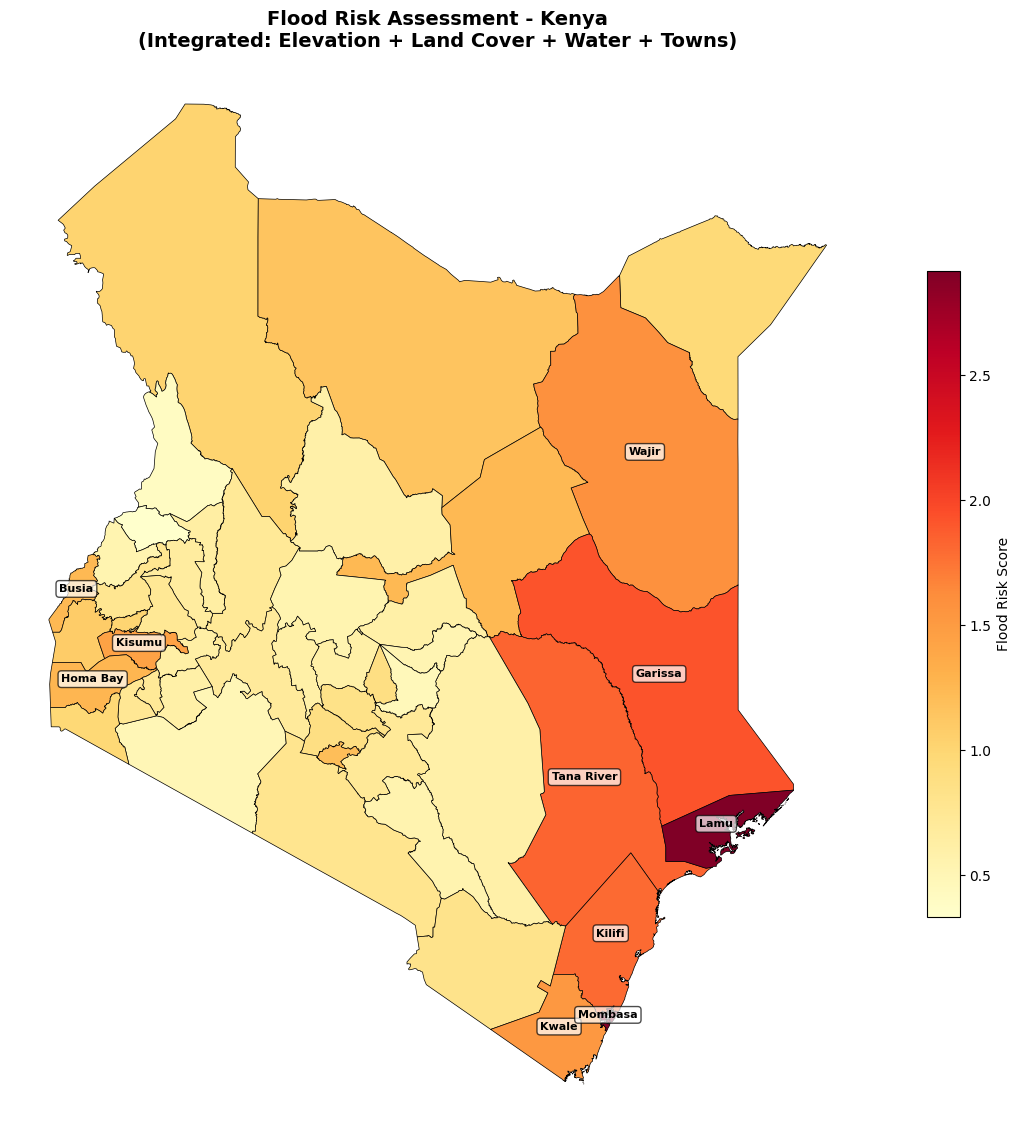

✅ Map saved


In [67]:
# Create flood risk map
print("🔄 CREATING FLOOD RISK MAP...")

# Merge risk data with counties
counties_gdf_proj = counties_gdf.to_crs(points_gdf.crs)
counties_with_risk = counties_gdf_proj.merge(county_stats, left_on='COUNTY_NAME', right_on='county', how='left')

fig, ax = plt.subplots(1, 1, figsize=(16, 14))

# Plot counties
counties_with_risk.plot(column='avg_risk', cmap='YlOrRd', linewidth=0.5,
                        edgecolor='black', legend=True, ax=ax,
                        legend_kwds={'label': 'Flood Risk Score', 'shrink': 0.6})

# Label top 10 risk counties
top_counties = county_stats.head(10)['county'].tolist()
for idx, row in counties_with_risk.iterrows():
    if row['COUNTY_NAME'] in top_counties:
        centroid = row.geometry.centroid
        ax.annotate(row['COUNTY_NAME'], xy=(centroid.x, centroid.y),
                   fontsize=8, ha='center', weight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

ax.set_title('Flood Risk Assessment - Kenya\n(Integrated: Elevation + Land Cover + Water + Towns)', 
             fontsize=14, fontweight='bold')
ax.set_axis_off()

map_path = os.path.join(output_folder, 'kenya_flood_risk_map.png')
plt.savefig(map_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Map saved")

In [68]:
# Save final dataset for machine learning
print("🔄 SAVING ML DATASET...")

ml_columns = ['county', 'nearest_town', 'town_size', 'landcover_types',
              'elevation_m', 'dist_to_town_m', 'dist_to_water_m',
              'topographic_hazard', 'landcover_risk', 'water_proximity_risk',
              'vulnerability_score', 'flood_risk_score', 'risk_category']

available_columns = [col for col in ml_columns if col in df_clean.columns]
ml_dataset = df_clean[available_columns].copy()

ml_dataset_path = os.path.join(output_folder, 'flood_risk_ml_dataset.csv')
ml_dataset.to_csv(ml_dataset_path, index=False)

print(f"✅ ML dataset saved: {ml_dataset_path}")
print(f"   Shape: {ml_dataset.shape}")
print(f"   Columns: {available_columns}")

# Create sample
sample_dataset = ml_dataset.sample(n=min(5000, len(ml_dataset)))
sample_path = os.path.join(output_folder, 'flood_risk_sample.csv')
sample_dataset.to_csv(sample_path, index=False)
print(f"✅ Sample dataset saved")

🔄 SAVING ML DATASET...
✅ ML dataset saved: c:\Users\PC\OneDrive\Desktop\Data Science\PERSONAL PROJECTS\Flood analysis\outputs\flood_risk_ml_dataset.csv
   Shape: (14497, 13)
   Columns: ['county', 'nearest_town', 'town_size', 'landcover_types', 'elevation_m', 'dist_to_town_m', 'dist_to_water_m', 'topographic_hazard', 'landcover_risk', 'water_proximity_risk', 'vulnerability_score', 'flood_risk_score', 'risk_category']
✅ Sample dataset saved


In [69]:
# Final summary
print("="*70)
print("🎉 FLOOD RISK ANALYSIS FOR KENYA - COMPLETE!")
print("="*70)

print("\n📊 FINAL STATISTICS:")
print(f"  Points analyzed: {len(df_clean):,}")
print(f"  Counties covered: {len(county_stats)}")
print(f"  Towns included: {len(towns_gdf) if towns_gdf is not None else 0}")
print(f"  Land cover types: {len(landcover_gdf)}")
print(f"  Average flood risk: {df_clean['flood_risk_score'].mean():.2f}")

print("\n🔴 TOP 10 HIGHEST RISK COUNTIES:")
for idx, row in county_stats.head(10).iterrows():
    bar = "█" * int(row['avg_risk'])
    print(f"  {row['county']:<25} {bar} {row['avg_risk']:.1f}")

print("\n📁 OUTPUT FILES:")
for file in os.listdir(output_folder):
    fpath = os.path.join(output_folder, file)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f"  • {file} ({size:.2f} MB)")

print("\n✅ Ready for Machine Learning and Policy Making!")

🎉 FLOOD RISK ANALYSIS FOR KENYA - COMPLETE!

📊 FINAL STATISTICS:
  Points analyzed: 14,497
  Counties covered: 47
  Towns included: 1620
  Land cover types: 10
  Average flood risk: 1.13

🔴 TOP 10 HIGHEST RISK COUNTIES:
  Lamu                      ██ 2.9
  Mombasa                   ██ 2.9
  Garissa                   █ 1.9
  Tana River                █ 1.8
  Kilifi                    █ 1.8
  Wajir                     █ 1.6
  Kwale                     █ 1.5
  Kisumu                    █ 1.4
  Homa Bay                  █ 1.3
  Busia                     █ 1.2

📁 OUTPUT FILES:
  • county_flood_risk_rankings.csv (0.00 MB)
  • dem_preview.png (0.32 MB)
  • flood_risk_ml_dataset.csv (1.44 MB)
  • flood_risk_sample.csv (0.49 MB)
  • kenya_counties_labeled.cpg (0.00 MB)
  • kenya_counties_labeled.dbf (0.02 MB)
  • kenya_counties_labeled.prj (0.00 MB)
  • kenya_counties_labeled.shp (2.93 MB)
  • kenya_counties_labeled.shx (0.00 MB)
  • kenya_flood_risk_map.png (0.28 MB)
  • kenya_towns_labeled.cp